In [2]:
#topic_modeling

In [3]:
# Setup + load data + validate 

import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("../results")
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path("../data/processed/reviews_preprocessed.csv")
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH.resolve())
print("n_samples:", len(df))
print("Columns:", list(df.columns))

# Hard checks
assert "clean_review" in df.columns, "clean_review missing"
assert "sentiment" in df.columns, "sentiment missing"

missing_clean = df["clean_review"].isna().sum()
empty_clean = (df["clean_review"].astype(str).str.strip() == "").sum()

print("Missing clean_review:", missing_clean)
print("Empty clean_review:", empty_clean)

print("\nSentiment counts:")
print(df["sentiment"].value_counts())

# Filter out empties just in case (should already be clean from Phase 3)
df = df[df["clean_review"].astype(str).str.strip() != ""].copy()
print("\nAfter dropping empty clean_review rows:", len(df))

Loaded: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\data\processed\reviews_preprocessed.csv
n_samples: 49998
Columns: ['review', 'clean_review', 'rating', 'sentiment', 'condition']
Missing clean_review: 0
Empty clean_review: 0

Sentiment counts:
sentiment
1    36324
0    13674
Name: count, dtype: int64

After dropping empty clean_review rows: 49998


In [4]:
# Unified plan (All + by-sentiment)

df_pos = df[df["sentiment"] == 1].copy()
df_neg = df[df["sentiment"] == 0].copy()

print("Mode A (ALL):", len(df))
print("Mode B (POS):", len(df_pos))
print("Mode B (NEG):", len(df_neg))

Mode A (ALL): 49998
Mode B (POS): 36324
Mode B (NEG): 13674


In [5]:
#  CountVectorizer

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Controls for interpretability
vectorizer = CountVectorizer(
    min_df=20,      # remove very rare words
    max_df=0.5,     # remove extremely common words
)

X_counts_all = vectorizer.fit_transform(df["clean_review"])

vocab = vectorizer.get_feature_names_out()

print("Document-term matrix shape (ALL):", X_counts_all.shape)
print("Vocabulary size:", len(vocab))

# Top 10 most frequent tokens (sanity check)
term_frequencies = np.asarray(X_counts_all.sum(axis=0)).flatten()
top_idx = np.argsort(term_frequencies)[-10:][::-1]

print("\nTop 10 most frequent tokens:")
for i in top_idx:
    print(vocab[i], "→", term_frequencies[i])

Document-term matrix shape (ALL): (49998, 4517)
Vocabulary size: 4517

Top 10 most frequent tokens:
be → 31532
day → 30264
take → 27457
have → 22871
feel → 20932
month → 20871
year → 20713
work → 19280
no → 18557
week → 17709


In [6]:
# Fit LDA (ALL)

from sklearn.decomposition import LatentDirichletAllocation

k = 10

lda_all = LatentDirichletAllocation(
    n_components=k,
    random_state=42,
    learning_method="batch",
    max_iter=10
)

lda_all.fit(X_counts_all)

print("LDA fitted.")
print("Number of topics (k):", k)

LDA fitted.
Number of topics (k): 10


In [7]:
# Export LDA top words (ALL) to topic_words.txt

TOP_N = 10
topic_words_path = RESULTS_DIR / "topic_words.txt"

def get_top_words(model, feature_names, topic_id, top_n=10):
    topic = model.components_[topic_id]
    top_idx = topic.argsort()[-top_n:][::-1]
    return [(feature_names[i], topic[i]) for i in top_idx]

with open(topic_words_path, "w", encoding="utf-8") as f:
    f.write("=== LDA (ALL) ===\n")
    for topic_id in range(k):
        words = get_top_words(lda_all, vocab, topic_id, TOP_N)
        f.write(f"\nTopic {topic_id}:\n")
        f.write(", ".join([f"{w}({weight:.1f})" for w, weight in words]))
        f.write("\n")

print("Saved LDA (ALL) topics to:", topic_words_path.resolve())

Saved LDA (ALL) topics to: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\results\topic_words.txt


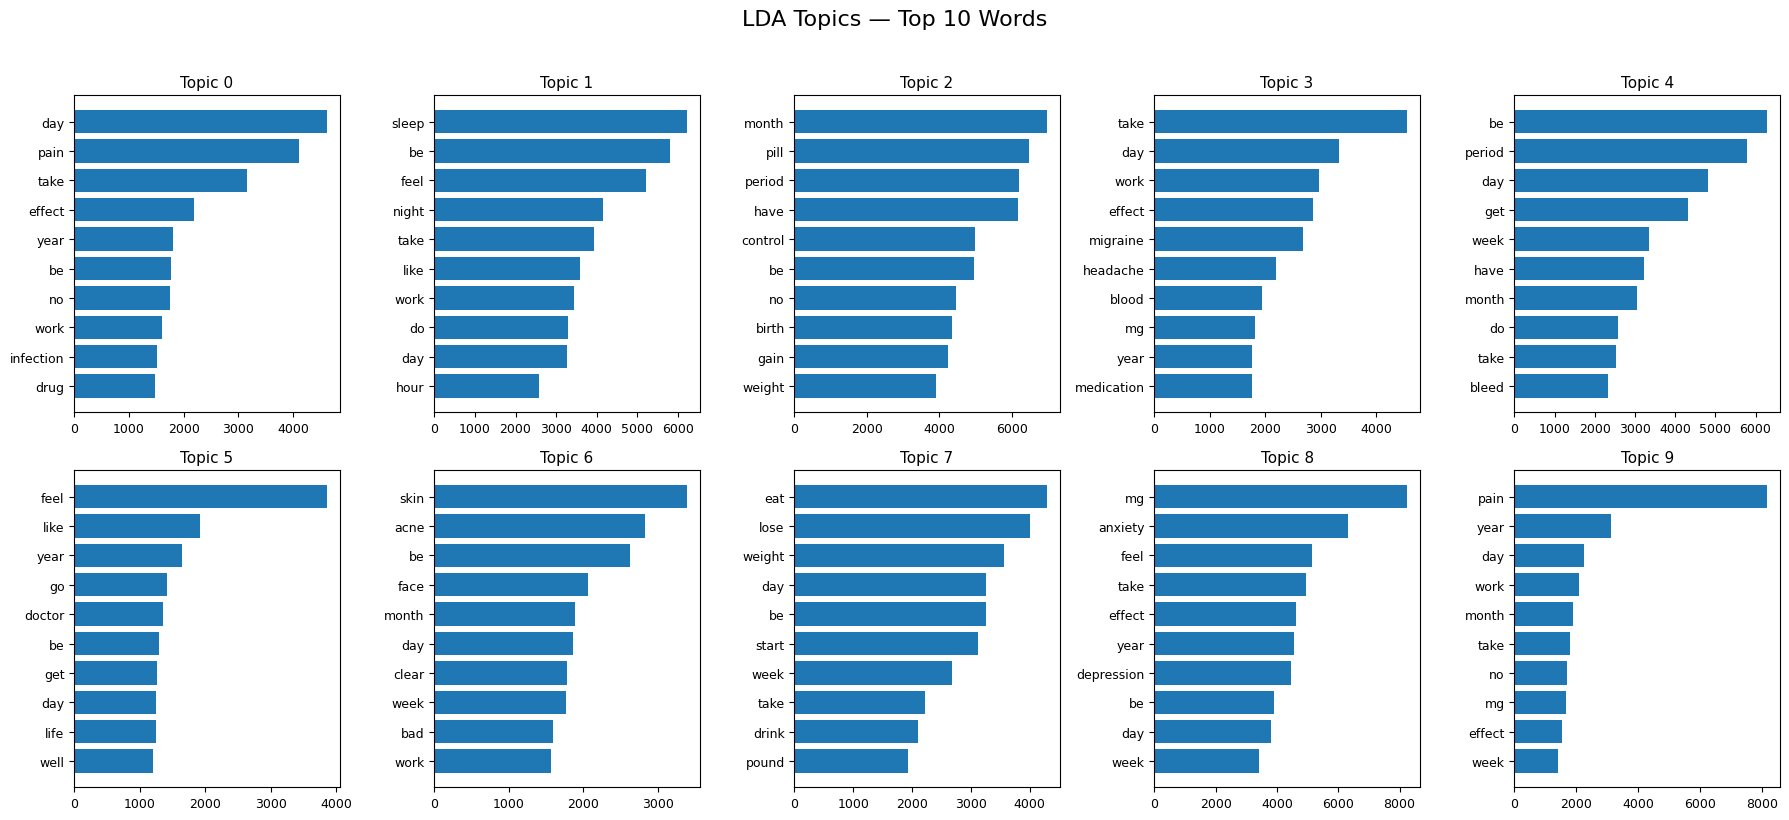

Saved: ..\results\figures\topic_lda_topic_words.png


In [8]:
# LDA Topic-Word bars (Top 10 words each topic)

import matplotlib.pyplot as plt
import numpy as np

TOP_N = 10
rows, cols = 2, 5

fig, axes = plt.subplots(rows, cols, figsize=(18, 8))
axes = axes.flatten()

for topic_id in range(k):
    topic = lda_all.components_[topic_id]
    top_idx = topic.argsort()[-TOP_N:][::-1]
    top_terms = [vocab[i] for i in top_idx][::-1]
    top_weights = topic[top_idx][::-1]

    ax = axes[topic_id]
    ax.barh(top_terms, top_weights)
    ax.set_title(f"Topic {topic_id}", fontsize=11)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

# Hide any unused axes (not needed here but safe)
for j in range(k, len(axes)):
    axes[j].axis("off")

fig.suptitle("LDA Topics — Top 10 Words", fontsize=16, y=1.02)
plt.tight_layout()

out_lda_words = FIG_DIR / "topic_lda_topic_words.png"
plt.savefig(out_lda_words, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_lda_words)

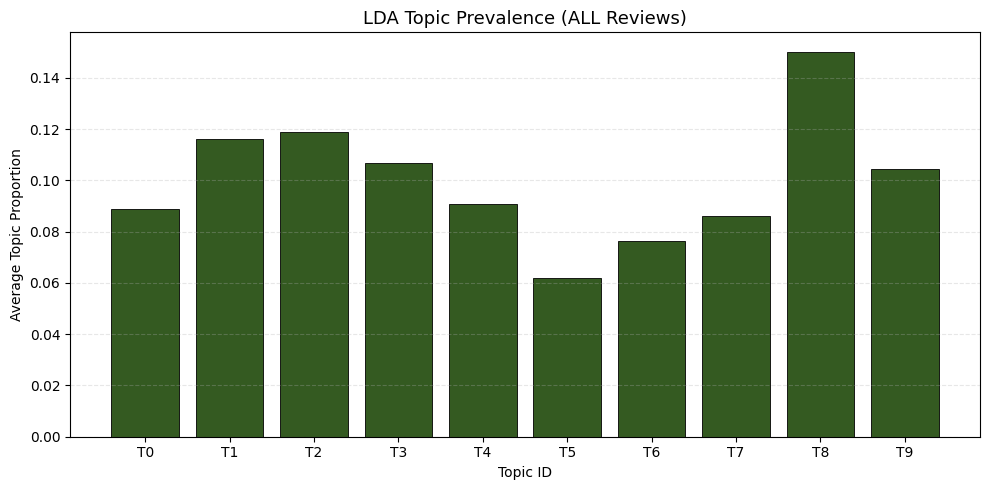

Saved: ..\results\figures\topic_lda_prevalence.png


In [9]:
# LDA topic prevalence 

doc_topic_all = lda_all.transform(X_counts_all)
topic_prevalence = doc_topic_all.mean(axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    range(k),
    topic_prevalence,
    color="#345A21",      # muted gray-blue
    edgecolor="black",
    linewidth=0.6
)

plt.title("LDA Topic Prevalence (ALL Reviews)", fontsize=13)
plt.xlabel("Topic ID")
plt.ylabel("Average Topic Proportion")
plt.xticks(range(k), [f"T{i}" for i in range(k)])

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

out_prev = FIG_DIR / "topic_lda_prevalence.png"
plt.savefig(out_prev, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_prev)

In [10]:
# LDA (POS only)

# Use SAME vectorizer settings for comparability
vectorizer_pos = CountVectorizer(min_df=20, max_df=0.5)
X_counts_pos = vectorizer_pos.fit_transform(df_pos["clean_review"])
vocab_pos = vectorizer_pos.get_feature_names_out()

lda_pos = LatentDirichletAllocation(
    n_components=k,
    random_state=42,
    learning_method="batch",
    max_iter=10
)

lda_pos.fit(X_counts_pos)

print("POS LDA fitted.")
print("POS document-term matrix:", X_counts_pos.shape)

POS LDA fitted.
POS document-term matrix: (36324, 3857)


In [11]:
# LDA (NEG only)

vectorizer_neg = CountVectorizer(min_df=20, max_df=0.5)
X_counts_neg = vectorizer_neg.fit_transform(df_neg["clean_review"])
vocab_neg = vectorizer_neg.get_feature_names_out()

lda_neg = LatentDirichletAllocation(
    n_components=k,
    random_state=42,
    learning_method="batch",
    max_iter=10
)

lda_neg.fit(X_counts_neg)

print("NEG LDA fitted.")
print("NEG document-term matrix:", X_counts_neg.shape)

NEG LDA fitted.
NEG document-term matrix: (13674, 2091)


In [12]:
# Append LDA POS and NEG topics

def write_lda_topics(model, vocab, header, file_path):
    with open(file_path, "a", encoding="utf-8") as f:
        f.write(f"\n\n=== {header} ===\n")
        for topic_id in range(k):
            topic = model.components_[topic_id]
            top_idx = topic.argsort()[-10:][::-1]
            words = [vocab[i] for i in top_idx]
            f.write(f"\nTopic {topic_id}:\n")
            f.write(", ".join(words))
            f.write("\n")

write_lda_topics(lda_pos, vocab_pos, "LDA (POS)", topic_words_path)
write_lda_topics(lda_neg, vocab_neg, "LDA (NEG)", topic_words_path)

print("Appended POS and NEG topics to:", topic_words_path.resolve())

Appended POS and NEG topics to: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\results\topic_words.txt


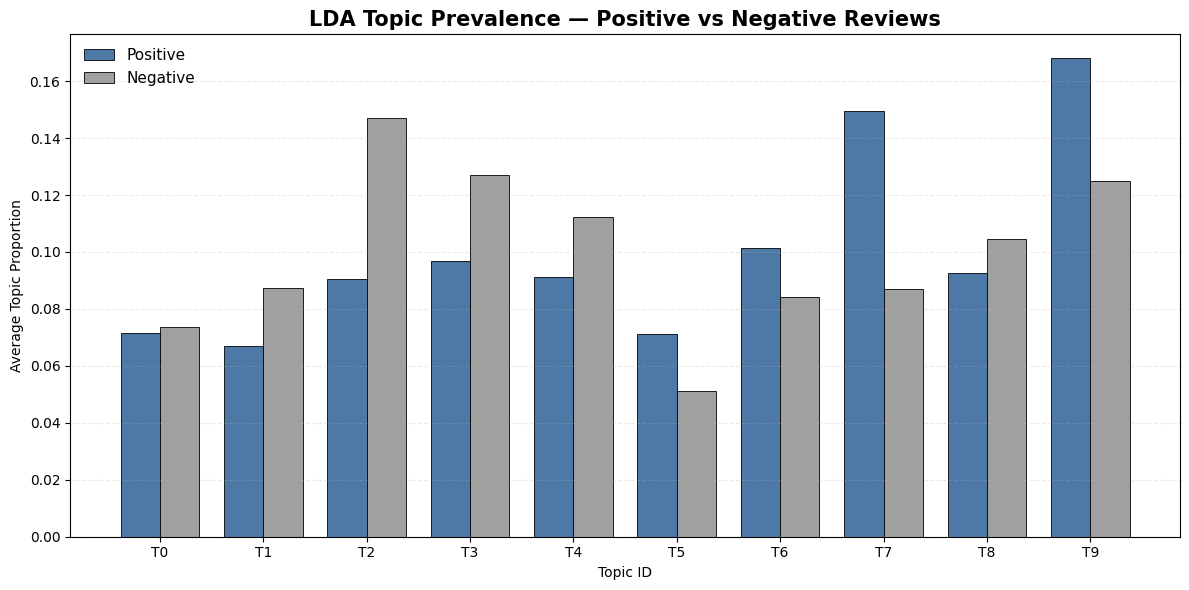

Saved: ..\results\figures\topic_lda_posneg_prevalence.png


In [13]:
#  POS vs NEG topic prevalence comparison
doc_topic_pos = lda_pos.transform(X_counts_pos)
doc_topic_neg = lda_neg.transform(X_counts_neg)

prev_pos = doc_topic_pos.mean(axis=0)
prev_neg = doc_topic_neg.mean(axis=0)

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(k)
width = 0.38

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2, prev_pos, width,
    label="Positive",
    color="#4E79A7",      # muted blue
    edgecolor="black",
    linewidth=0.6
)

plt.bar(
    x + width/2, prev_neg, width,
    label="Negative",
    color="#A0A0A0",      # neutral gray
    edgecolor="black",
    linewidth=0.6
)
plt.title("LDA Topic Prevalence — Positive vs Negative Reviews",
          fontsize=15, fontweight="bold")
plt.xlabel("Topic ID")
plt.ylabel("Average Topic Proportion")
plt.xticks(x, [f"T{i}" for i in range(k)])

plt.legend(frameon=False,fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()

out_posneg = FIG_DIR / "topic_lda_posneg_prevalence.png"
plt.savefig(out_posneg, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_posneg)

In [14]:
# Load embeddings for BERTopic + sanity checks

import numpy as np
from pathlib import Path

EMB_PATH = Path("../data/features/bert_embeddings.npy")

embeddings = np.load(EMB_PATH)
print("Loaded embeddings from:", EMB_PATH.resolve())
print("Embeddings shape:", embeddings.shape)

# Alignment check: embeddings rows must match df rows
print("Text rows:", len(df))
assert embeddings.shape[0] == len(df), "Mismatch: embeddings rows != df rows"

print("OK: embeddings aligned with texts.")

Loaded embeddings from: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\data\features\bert_embeddings.npy
Embeddings shape: (49998, 384)
Text rows: 49998
OK: embeddings aligned with texts.


In [15]:
# Cell 13 — BERTopic imports 

try:
    from bertopic import BERTopic
    import umap
    import hdbscan
    print("BERTopic + deps loaded.")
except ModuleNotFoundError as e:
    print("Missing package:", e)
    print("Run this in a new cell:")
    print("!pip install bertopic umap-learn hdbscan")

BERTopic + deps loaded.


In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load dataset
DATA_PATH = Path("../data/processed/reviews_preprocessed.csv")
df = pd.read_csv(DATA_PATH)

# Load embeddings
EMB_PATH = Path("../data/features/bert_embeddings.npy")
embeddings = np.load(EMB_PATH)

print("Data shape:", df.shape)
print("Embeddings shape:", embeddings.shape)

assert len(df) == embeddings.shape[0], "Mismatch between df and embeddings"
print("OK: Data reloaded and aligned.")

Data shape: (49998, 5)
Embeddings shape: (49998, 384)
OK: Data reloaded and aligned.


In [17]:
# BERTopic (ALL) with PCA + KMeans (no UMAP / no HDBSCAN)

import numpy as np
from bertopic import BERTopic
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

RANDOM_STATE = 42
N_SAMPLE = 5000          # keep 5000; can raise later if it runs
N_TOPICS = 15            # fixed number of clusters/topics for stable comparison

# Stratified sampling (same as before)
df_reset = df.reset_index(drop=True)
idx_pos = df_reset[df_reset["sentiment"] == 1].index.to_numpy()
idx_neg = df_reset[df_reset["sentiment"] == 0].index.to_numpy()

n_pos = int(round(N_SAMPLE * (len(idx_pos) / len(df_reset))))
n_neg = N_SAMPLE - n_pos

rng = np.random.default_rng(RANDOM_STATE)
s_pos = rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False)
s_neg = rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False)

sample_idx = np.concatenate([s_pos, s_neg])
rng.shuffle(sample_idx)

docs_all = df_reset.loc[sample_idx, "clean_review"].astype(str).tolist()
emb_all = embeddings[sample_idx].astype(np.float32)

print("Sampled docs:", len(docs_all))
print("Sample class counts:\n", df_reset.loc[sample_idx, "sentiment"].value_counts())
print("Embeddings sample shape:", emb_all.shape, emb_all.dtype)

# PCA reduction (fast + low memory)
pca_model = PCA(n_components=5, random_state=RANDOM_STATE)

# KMeans clustering (fast + low memory)
kmeans_model = KMeans(n_clusters=N_TOPICS, random_state=RANDOM_STATE, n_init=10)

topic_model_all = BERTopic(
    language="english",
    umap_model=pca_model,       # BERTopic accepts any model with fit_transform
    hdbscan_model=kmeans_model, # BERTopic accepts any clustering model with fit_predict
    calculate_probabilities=False,
    verbose=True
)

topics_all, _ = topic_model_all.fit_transform(docs_all, emb_all)

topic_info_all = topic_model_all.get_topic_info()
n_topics = int((topic_info_all["Topic"] != -1).sum())

print("\n===== BERTopic (ALL) SUMMARY (PCA+KMeans) =====")
print("Docs used:", len(docs_all))
print("Topics (kmeans clusters):", n_topics)
print("==============================================")

2026-02-25 01:53:57,799 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-25 01:53:57,884 - BERTopic - Dimensionality - Completed ✓
2026-02-25 01:53:57,886 - BERTopic - Cluster - Start clustering the reduced embeddings


Sampled docs: 5000
Sample class counts:
 sentiment
1    3633
0    1367
Name: count, dtype: int64
Embeddings sample shape: (5000, 384) float32


  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1491, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro


===== BERTopic (ALL) SUMMARY (PCA+KMeans) =====
Docs used: 5000
Topics (kmeans clusters): 15


In [18]:
# Append BERTopic (ALL) topics to topic_words.txt (top 10 words + topic size)

topic_info_all = topic_model_all.get_topic_info()

with open(topic_words_path, "a", encoding="utf-8") as f:
    f.write("\n\n=== BERTopic (ALL) [PCA+KMeans, stratified sample=5000] ===\n")
    for _, row in topic_info_all.iterrows():
        topic_id = int(row["Topic"])
        count = int(row["Count"])
        if topic_id == -1:
            continue  # KMeans usually won't produce -1, but keep safe

        words = topic_model_all.get_topic(topic_id)  # list of (word, weight)
        top_words = [w for w, _ in words[:10]]

        f.write(f"\nTopic {topic_id} (n={count}):\n")
        f.write(", ".join(top_words))
        f.write("\n")

print("Appended BERTopic (ALL) topics to:", topic_words_path.resolve())
print("Topics listed:", (topic_info_all["Topic"] != -1).sum())

Appended BERTopic (ALL) topics to: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\results\topic_words.txt
Topics listed: 15


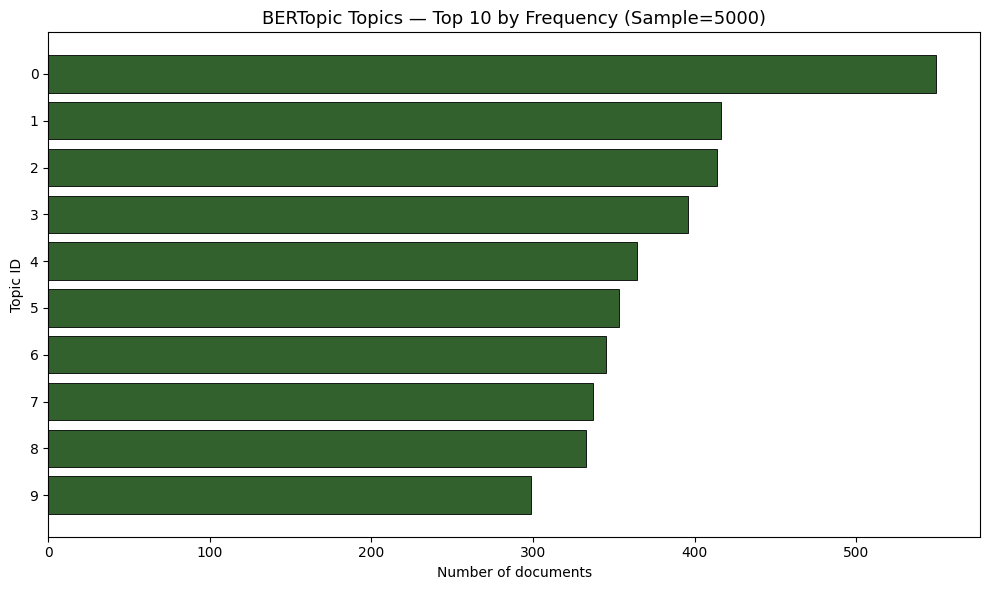

Saved: ..\results\figures\topic_bertopic_barchart.png


In [21]:
#BERTopic barchart 
import matplotlib.pyplot as plt

topic_info_all = topic_model_all.get_topic_info()
topic_info_plot = topic_info_all[topic_info_all["Topic"] != -1].copy()
topic_info_plot = topic_info_plot.sort_values("Count", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    topic_info_plot["Topic"].astype(str)[::-1],
    topic_info_plot["Count"][::-1],
    color="#32612D",
    edgecolor="black",
    linewidth=0.6
)
plt.title("BERTopic Topics — Top 10 by Frequency (Sample=5000)", fontsize=13)
plt.xlabel("Number of documents")
plt.ylabel("Topic ID")
plt.tight_layout()

out_bt_bar = FIG_DIR / "topic_bertopic_barchart.png"
plt.savefig(out_bt_bar, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_bt_bar)

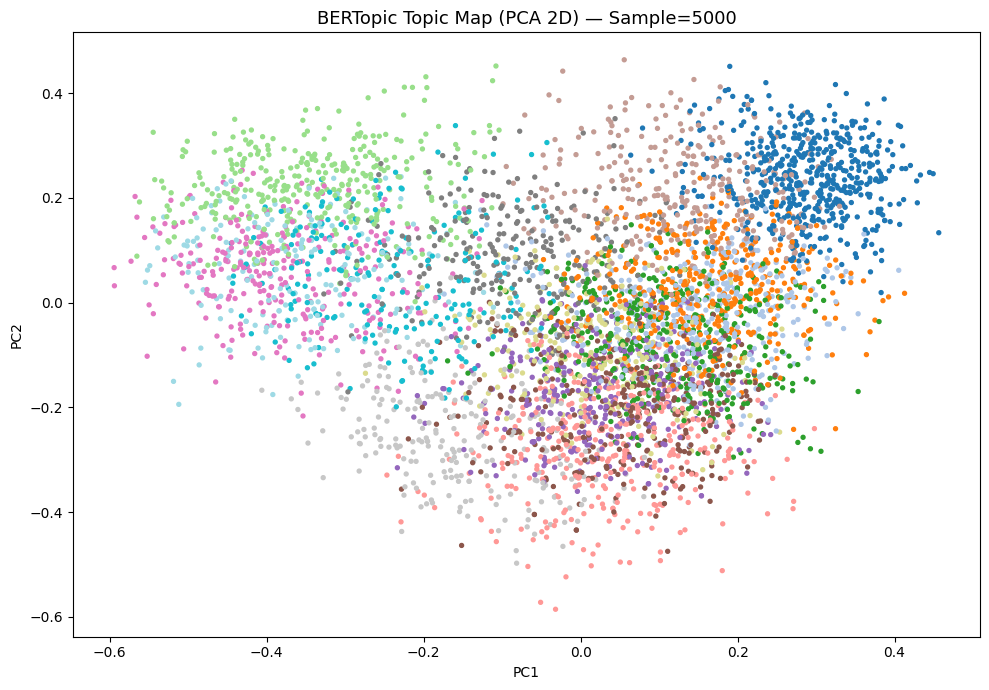

Saved: ..\results\figures\topic_bertopic_map.png


In [22]:
#BERTopic 2D Topic Map (PCA projection)
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 2D projection of the sampled embeddings
pca2 = PCA(n_components=2, random_state=42)
emb_2d = pca2.fit_transform(emb_all)

topics_arr = np.array(topics_all)

plt.figure(figsize=(10, 7))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=topics_arr,
    s=8,
    cmap="tab20"
)

plt.title("BERTopic Topic Map (PCA 2D) — Sample=5000", fontsize=13)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

out_bt_map = FIG_DIR / "topic_bertopic_map.png"
plt.savefig(out_bt_map, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_bt_map)

In [23]:
#BERTopic on Positive Reviews (PCA + KMeans)
# ---- POSITIVE ONLY ----
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from bertopic import BERTopic

RANDOM_STATE = 42
N_POS_SAMPLE = 4000

df_pos = df[df["sentiment"] == 1].reset_index(drop=True)

rng = np.random.default_rng(RANDOM_STATE)
sample_idx_pos = rng.choice(len(df_pos), size=min(N_POS_SAMPLE, len(df_pos)), replace=False)

docs_pos = df_pos.loc[sample_idx_pos, "clean_review"].astype(str).tolist()
emb_pos = embeddings[df[df["sentiment"] == 1].index][sample_idx_pos].astype(np.float32)

print("POS docs:", len(docs_pos))

# PCA reduction
pca_model = PCA(n_components=5, random_state=RANDOM_STATE)

# KMeans clustering
kmeans_model = KMeans(n_clusters=12, random_state=RANDOM_STATE, n_init=10)

topic_model_pos = BERTopic(
    umap_model=pca_model,
    hdbscan_model=kmeans_model,
    calculate_probabilities=False,
    verbose=True
)

topics_pos, _ = topic_model_pos.fit_transform(docs_pos, emb_pos)

print("POS topics found:", len(set(topics_pos)))

2026-02-25 02:10:26,434 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


POS docs: 4000


2026-02-25 02:10:26,522 - BERTopic - Dimensionality - Completed ✓
2026-02-25 02:10:26,527 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-25 02:10:26,775 - BERTopic - Cluster - Completed ✓
2026-02-25 02:10:26,794 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-25 02:10:27,107 - BERTopic - Representation - Completed ✓


POS topics found: 12


In [24]:
#BERTopic on Negative Reviews
# ---- NEGATIVE ONLY ----
RANDOM_STATE = 42
N_NEG_SAMPLE = 4000

df_neg = df[df["sentiment"] == 0].reset_index(drop=True)

rng = np.random.default_rng(RANDOM_STATE)
sample_idx_neg = rng.choice(len(df_neg), size=min(N_NEG_SAMPLE, len(df_neg)), replace=False)

docs_neg = df_neg.loc[sample_idx_neg, "clean_review"].astype(str).tolist()
emb_neg = embeddings[df[df["sentiment"] == 0].index][sample_idx_neg].astype(np.float32)

print("NEG docs:", len(docs_neg))

pca_model = PCA(n_components=5, random_state=RANDOM_STATE)
kmeans_model = KMeans(n_clusters=12, random_state=RANDOM_STATE, n_init=10)

topic_model_neg = BERTopic(
    umap_model=pca_model,
    hdbscan_model=kmeans_model,
    calculate_probabilities=False,
    verbose=True
)

topics_neg, _ = topic_model_neg.fit_transform(docs_neg, emb_neg)

print("NEG topics found:", len(set(topics_neg)))

2026-02-25 02:13:11,212 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-25 02:13:11,289 - BERTopic - Dimensionality - Completed ✓
2026-02-25 02:13:11,293 - BERTopic - Cluster - Start clustering the reduced embeddings


NEG docs: 4000


2026-02-25 02:13:11,455 - BERTopic - Cluster - Completed ✓
2026-02-25 02:13:11,460 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-25 02:13:11,700 - BERTopic - Representation - Completed ✓


NEG topics found: 12


In [25]:
#Print Top Words (POS vs NEG)
print("===== POSITIVE TOPICS =====")
for topic_id in sorted(set(topics_pos)):
    words = topic_model_pos.get_topic(topic_id)
    if words:
        top_words = [w for w, _ in words[:10]]
        print(f"POS Topic {topic_id}: {', '.join(top_words)}")

print("\n===== NEGATIVE TOPICS =====")
for topic_id in sorted(set(topics_neg)):
    words = topic_model_neg.get_topic(topic_id)
    if words:
        top_words = [w for w, _ in words[:10]]
        print(f"NEG Topic {topic_id}: {', '.join(top_words)}")

===== POSITIVE TOPICS =====
POS Topic 0: anxiety, mg, feel, depression, not, take, be, life, year, medication
POS Topic 1: migraine, mg, take, pain, not, day, headache, sleep, effect, work
POS Topic 2: not, year, life, day, be, work, drug, feel, effect, take
POS Topic 3: day, not, take, stomach, work, no, pain, be, time, hour
POS Topic 4: pain, not, work, relief, day, take, help, knee, injection, year
POS Topic 5: year, day, not, work, eye, no, be, effect, infection, week
POS Topic 6: period, pill, not, month, have, birth, be, control, get, day
POS Topic 7: lose, weight, eat, pound, start, not, day, week, lbs, take
POS Topic 8: work, not, year, great, good, be, day, no, effect, life
POS Topic 9: period, cramp, not, insertion, be, insert, have, mirena, get, day
POS Topic 10: acne, skin, face, clear, month, not, be, bad, dry, result
POS Topic 11: period, acne, month, have, pill, not, birth, gain, control, be

===== NEGATIVE TOPICS =====
NEG Topic 0: anxiety, not, mg, feel, depression, ta

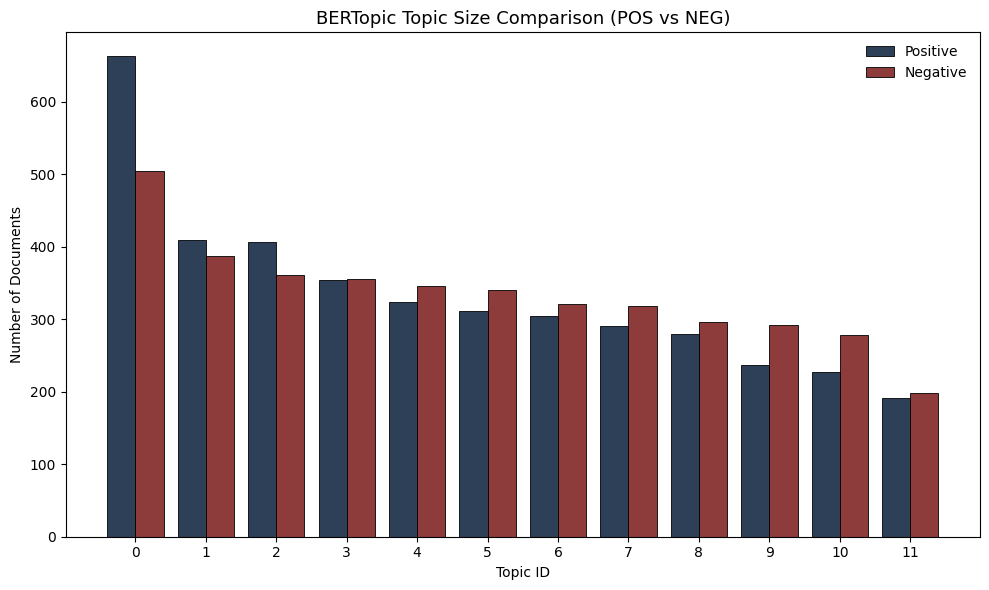

In [27]:
#Compare Topic Size Distributions (POS vs NEG)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pos_counts = pd.Series(topics_pos).value_counts().sort_index()
neg_counts = pd.Series(topics_neg).value_counts().sort_index()

x = np.arange(len(pos_counts))

plt.figure(figsize=(10, 6))

plt.bar(
    x - 0.2,
    pos_counts.values,
    width=0.4,
    color="#2E4057",        # muted dark blue-grey
    edgecolor="black",
    linewidth=0.6,
    label="Positive"
)

plt.bar(
    x + 0.2,
    neg_counts.values,
    width=0.4,
    color="#8D3B3B",        # muted dark red
    edgecolor="black",
    linewidth=0.6,
    label="Negative"
)

plt.xticks(x, pos_counts.index)
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.title("BERTopic Topic Size Comparison (POS vs NEG)", fontsize=13)
plt.legend(frameon=False)
plt.tight_layout()

plt.show()